In [321]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from lmfit import Parameters, minimize
from psyduck.operations import get_spin_operators
from psyduck.hamiltonians import quadrupole_hamiltonian_from_Vab, zeeman_hamiltonian, get_fq1, get_fq2, get_quadrupole_stark_shift
from psyduck.tensors import get_R_tensor, voigt_to_tensor
from psyduck.plotting import plot_quadrupole_tensor, spherical_plot_3d, spherical_plot_hammer, spherical_plot_3d_with_projections

In [322]:
Ix, Iy, Iz = get_spin_operators(7/2)

# Physical constants for Sb-123
Q_N = -0.69e-28    # Nuclear quadrupole moment (C·m²)
I_SPIN = 7/2
GAMMA_NUCLEAR = 5.55 * 1e6 # Nuclear Zeeman splitting (MHz/T)

In [377]:
#round 1

nmr = np.array([[5172791, 5192239, 5211740, 5231304, 5250923, 5270595, 5290345],
                [5160688, 5168255, 5176257, 5184657, 5193455, 5202655, 5212240],
                [5193539, 5182071, 5171162, 5160824, 5151057, 5141862, 5133238],
                [5059454, 5031774, 5004403, 4977343, 4950602, 4924210, 4898143],
                [4979932, 4949389, 4918974, 4888688, 4858533, 4828508, 4798611],
                # [4999724, 4982724, 4965998, 4949547, 4933377, 4917481, 4901852],
                # [5104750, 5108384, 5112255, 5116361, 5120679, 5125222, 5129953]
                ])
thetas = np.array([0, 22.5, 45, 67.5, 90])/180*np.pi
fq_1_measured = np.mean(np.diff(nmr, axis=1), axis=1)
fq_2_measured = np.mean(np.diff(np.diff(nmr, axis=1), axis=1), axis=1)
fq_3_measured = np.mean(np.diff(np.diff(np.diff(nmr, axis=1), axis=1), axis=1), axis=1)
f_ner1_measured = 0.5*np.array([
    [ 1/519697,  1/597295, 1/1064037, 0, 1/1076182, 1/592020, 1/507312],
    [ 1/686240, 1/781800, 1/1392608, 0, 1/1432536,  1/794038,  1/684887],
    [ 1/724982, 1/820604, 1/1461844, 0, 1/1471447,  1/819658,  1/702738],
    [1/1007362, 1/1139615, 1/2027774, 0,  1/2062878, 1/1141658,  1/983045],
    [1/3287934, 1/3776028, 1/6466973, 0, 1/6156559, 1/3433791, 1/3061009],
    # [1/2681059, 1/3073828, 1/5336330, 0, 1/5658708, 1/3075752, 1/2609055],
    # [1/1133288, 1/1313658, 1/2285002, 0, 1/2434721, 1/1315950, 1/1105150]
]) * 1e9
c = 1/0.5
f_ner2_measured = 0.5*np.array([
    [6199939,  4560535, 3957246, 3999002, 4549282,  6302998],
    [5964587, 4554291, 3907868, 3985586, 4576766, 6594215],
     [3042804, 2118640, 1842177, 1828053, 2099015, 3039585],
    [2028237, 1397648, 1206481, 1203026, 1370836, 1985169],
    [1882414, 1288540, 1109672, 1106511, 1269216, 1831437],
    # [c*976274, c*681467, c*584440, c*589394, c*675320, c*983801],
    # [c*1084931, c*748730, c*639388, c*647135, c*747695, c*1081884]
]) * 1e9
lqse_measured = -np.array([100/0.75, 88.529, -5.351, -102.260, -135.221])
                                   # -72.705, 43.519])

In [339]:
# round 2

nmr = np.array([
    [5177528, 5196914, 5216357, 5235865, 5255417, 5275028, 5294686],
    [5161529, 5169044, 5176984, 5185315, 5194063, 5203187, 5212704],
    [5193097, 5181625, 5170701, 5160363, 5150582, 5141366, 5132727],
    [5061216, 5033579, 5006232, 4979215, 4952508, 4926134, 4900099],
    [4979932, 4949389, 4918974, 4888688, 4858533, 4828508, 4798611],
    [4999724, 4982724, 4965998, 4949547, 4933377, 4917481, 4901852],
    [5104750, 5108384, 5112255, 5116361, 5120679, 5125222, 5129953],
    [5097951, 5116198, 5134431, 5152658, 5170888, 5189117, 5207340],
    [5175598, 5195010, 5214485, 5234018, 5253596, 5273241, 5292925]
])
thetas = np.array([0, 22.5, 45, 67.5, 90, 112.5, 135, 157.5, 180])/180*np.pi
fq_1_measured = np.mean(np.diff(nmr, axis=1), axis=1)
fq_2_measured = np.mean(np.diff(np.diff(nmr, axis=1), axis=1), axis=1)
fq_3_measured = np.mean(np.diff(np.diff(np.diff(nmr, axis=1), axis=1), axis=1), axis=1)
f_ner1_measured = 0.5*np.array([
    [1/519697, 1/597295, 1/1064037, 0, 1/1076182,  1/592020,  1/507312],
    [1/469814, 1/537820, 1/964855, 0, 1/959450, 1/539029, 1/467321],
    [1/474313, 1/543768, 1/961922, 0, 1/980673, 1/543890, 1/474970],
    [ 1/599094,  1/679474, 1/1198854, 0, 1/1226728,  1/681987, 1/591860],
    [1/1081992.81, 1/1251703.02, 1/2229890.79, 0, 1/2181519.21, 1/1243226.88, 1/1076215.2],
    [1/2681059, 1/3073828, 1/5336330, 0, 1/5658708, 1/3075752, 1/2609055],
    [1/1133288, 1/1313658, 1/2285002, 0, 1/2434721, 1/1315950, 1/1105150],
    [ 1/682572,  1/778685, 1/1394757, 0, 1/1420564,  1/787685,  1/679665],
    [ 1/530590,  1/607428, 1/1088738, 0,  1/1100366,  1/604772,  1/526999]

]) * 1e9
# c = 1/0.5
f_ner2_measured = 0.5/np.array([
    [2059393, 1470940, 1278560, 1282440, 1452975, 2048745],
    [5575075, 4523979, 3669188, 3740429, 4140198, 5637024],
    [3845992, 2585353, 2204919, 2232682, 2553333, 3571300],
    [1523368, 1068814, 930864, 930000, 1068814, 1523368],
    [1093055, 759243, 660288, 657546, 752941, 1060455],
    [976274, 681467, 584440, 589394, 675320, 983801],
    [1084931, 748730, 639388, 647135, 747695, 1081884],
    [1471040, 1051061, 885124, 895757, 1025554, 1486298],
    [2185740, 1563971, 1390545, 1398118, 1606166, 2275523]
]) * 1e9
lqse_measured = np.array([167.239, 120.834, -0.684, -105.872, -149.260, -72.705, 43.519, 132.189, 152.620])

In [340]:
nmr.shape

(9, 7)

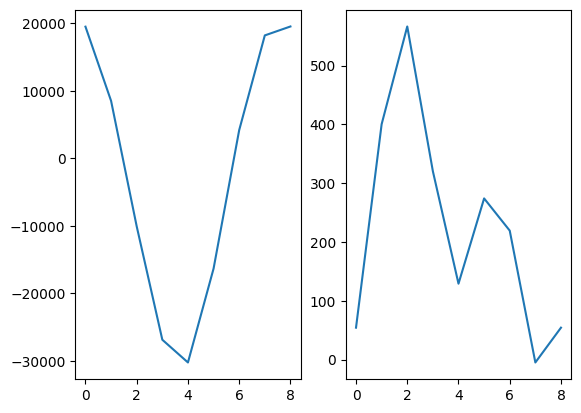

In [341]:
fig, ax = plt.subplots(1,2)
ax[0].plot(fq_1_measured)
ax[1].plot(fq_2_measured)

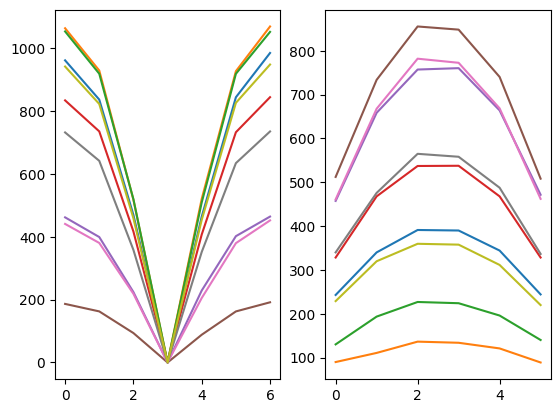

In [342]:
fig, ax = plt.subplots(1,2)
ax[0].plot(f_ner1_measured.T)
ax[1].plot(f_ner2_measured.T)

In [343]:
B0 = np.mean(nmr[0])/GAMMA_NUCLEAR

def make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz):
    return np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

def ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=0.0, **kwargs):
    V_ab = make_V_ab(Vxx, Vyy, Vzz, Vxy, Vyz, Vxz)
    H_q = quadrupole_hamiltonian_from_Vab(I_SPIN, V_ab, Q_N)
    H_zeeman = zeeman_hamiltonian(7/2, B0=B0, gamma=GAMMA_NUCLEAR, theta=theta, phi=phi)
    return H_zeeman + H_q

# R-tensor (Si, (110) orientation): maps AC field [Ex, Ey, Ez] → EFG Voigt vector
_R_tensor = get_R_tensor()   # (6, 3)

def _drive_in_eigenbasis(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=0.0):
    """Drive Hamiltonian (from AC field E_ac) in the energy eigenbasis of H_ion."""
    E_ac       = np.array([E_x, E_y, E_z])
    EFG_tensor = voigt_to_tensor(_R_tensor @ E_ac)
    H_drive    = quadrupole_hamiltonian_from_Vab(I_SPIN, EFG_tensor, Q_N).full()
    H_ion      = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=phi)
    _, evecs   = H_ion.eigenstates()
    U          = np.column_stack([v.full().flatten() for v in evecs])
    return U.conj().T @ H_drive @ U

def ner1(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=0.0, **kwargs):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=phi), 1))

def ner2(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, phi=0.0, scale=1.0, **kwargs):
    return np.abs(np.diag(_drive_in_eigenbasis(
        theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, scale*E_x, scale*E_y, scale*E_z, phi=phi), 2))

def nmr_frequencies(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=0.0, **kwargs):
    evals = ionized_hamiltonian(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, phi=phi).eigenstates()[0]
    return np.flip(np.diff(evals)).flatten()

def lqse(theta, Vxx, Vyy, Vzz, Vxy, Vyz, Vxz, E_x, E_y, E_z, scale_dc=1.0, **kwargs):
    V_ab = voigt_to_tensor(np.array([Vxx, Vyy, Vzz, Vxy, Vyz, Vxz]))
    E_vec = np.array([E_x, E_y, E_z])
    dfq1_stark, dfq2_stark = get_quadrupole_stark_shift(
        V_ab, E_vec, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, thetas=np.array([theta]), phis=np.array([0])
    )
    return scale_dc * dfq1_stark[0, 0]

In [344]:
B0

np.float64(0.9434181467181467)

In [345]:

def residual(params):
    p = params.valuesdict()
    fq1_arr = np.zeros(len(thetas))
    fq2_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    return np.vstack([
        (fq1_arr - fq_1_measured) / np.max(fq_1_measured),
        (fq2_arr - fq_2_measured) / np.max(fq_2_measured),
    ])

params = Parameters()
params.add('Vxx', value=0, min=-5,  max=5)
params.add('Vyy', value=0,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=-1.33,  min=-20, max=20)
params.add('Vyz', value=-1.65,  min=-5,  max=20)
params.add('Vxz', value=0.81,  min=-5,  max=20)
# params.add('scale', value=0, min=0, max=0.1)

result = minimize(residual, params, method='leastsq')
result.params.pretty_print()

Name     Value      Min      Max   Stderr     Vary     Expr Brute_Step
Vxx     2.416       -5        5  0.03852     True     None     None
Vxy    -1.466      -20       20  0.06106     True     None     None
Vxz    0.5942       -5       20  0.03109     True     None     None
Vyy   -0.7097       -5        5  0.04664     True     None     None
Vyz    -1.202       -5       20   0.0583     True     None     None
Vzz    -1.707     -inf      inf  0.03292    False - Vxx - Vyy     None


In [346]:
result

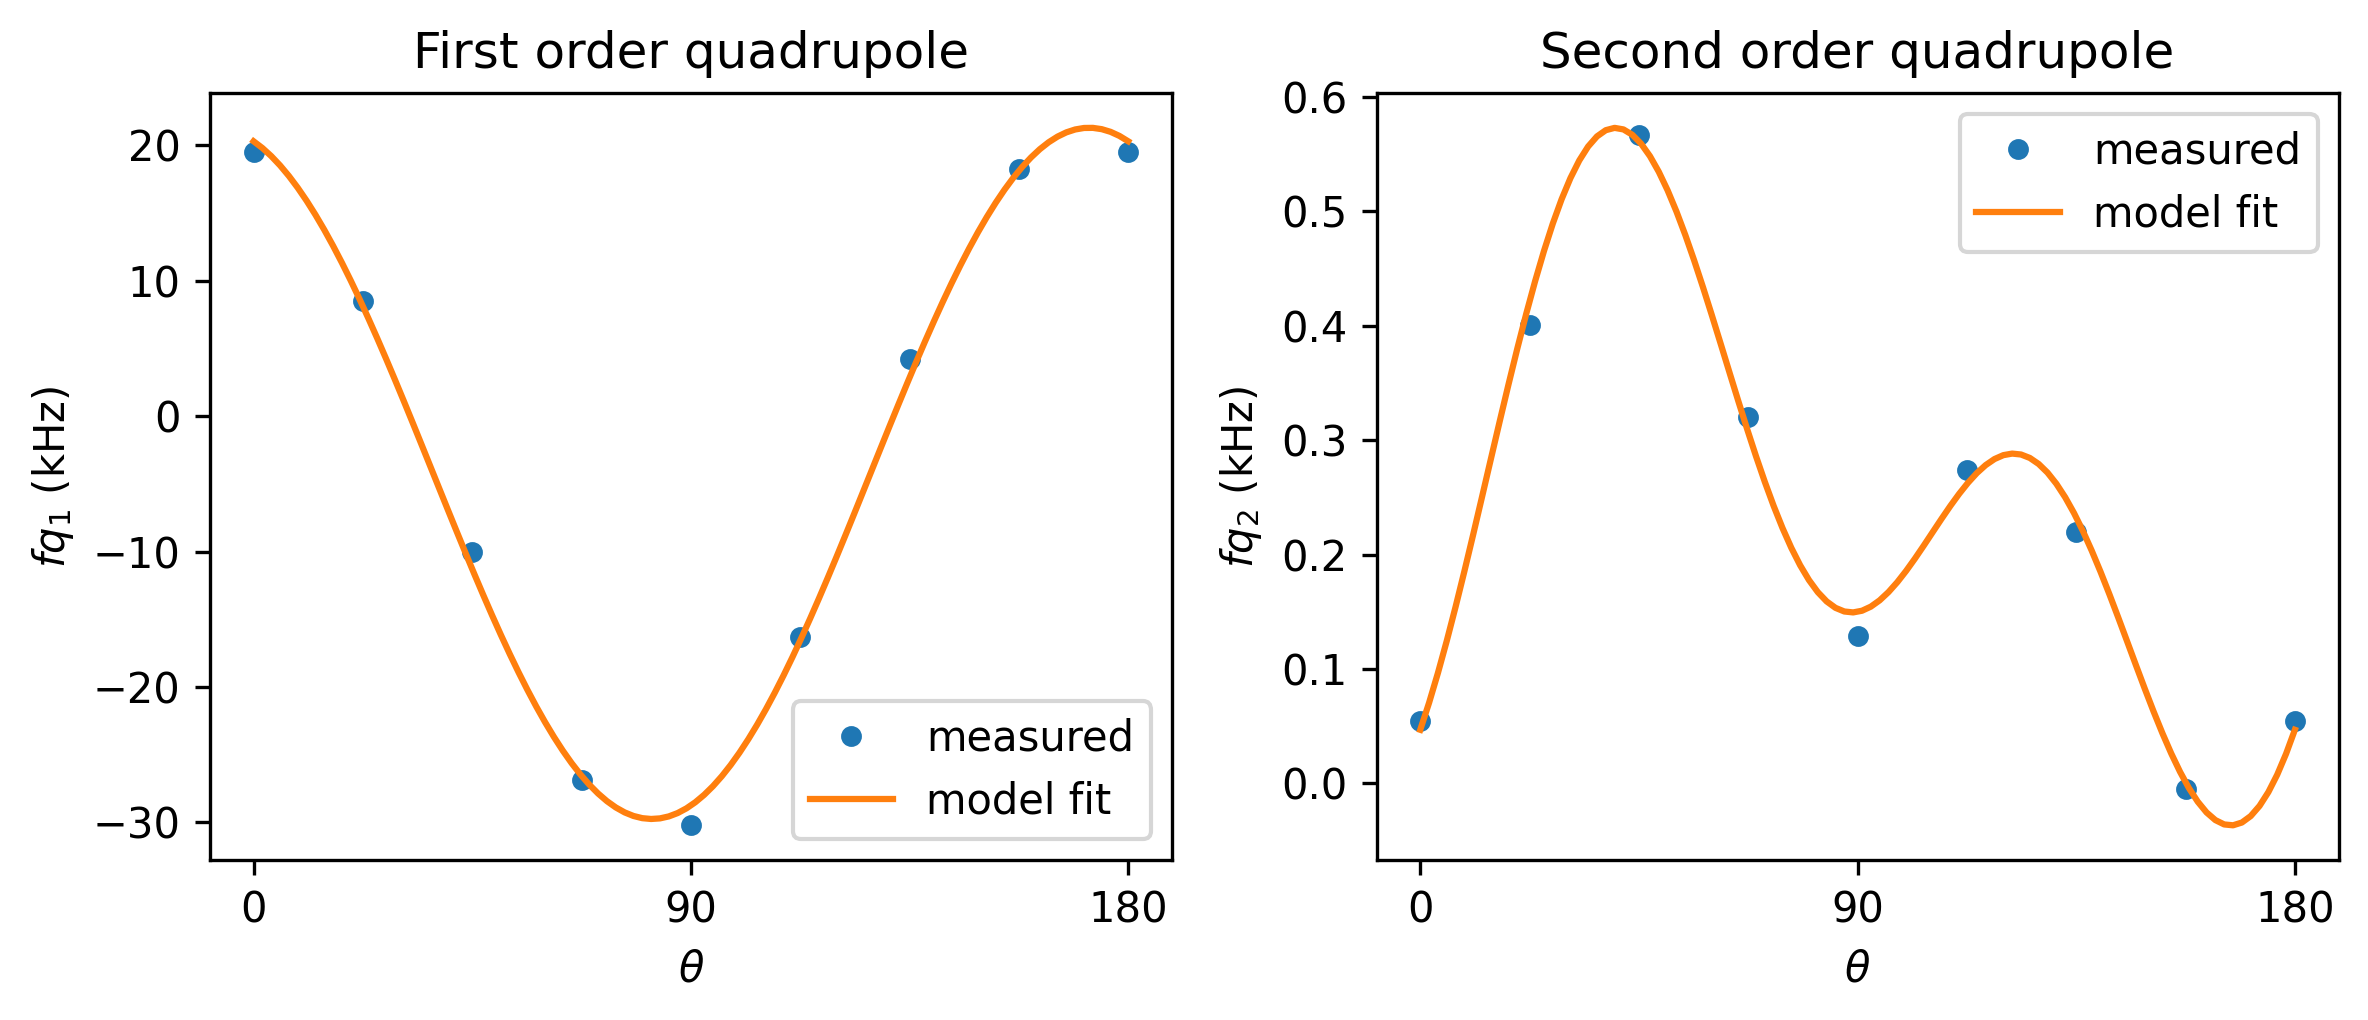

In [347]:
p = result.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)
fq1_arr = np.zeros(len(thetas_fit))
fq2_arr = np.zeros(len(thetas_fit))
fq3_arr = np.zeros(len(thetas_fit))
for t, theta in enumerate(thetas_fit):
    evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
    fq1_arr[t] = np.mean(np.diff(np.diff(evals)))
    fq2_arr[t] = np.mean(np.diff(np.diff(np.diff(evals))))
    fq3_arr[t] = np.mean(np.diff(np.diff(np.diff(np.diff(evals)))))

fig, ax = plt.subplots(1, 2, figsize=(8, 3.5), dpi=300)
ax[0].plot(thetas / np.pi * 180, fq_1_measured * 1e-3, '.', markersize=8, label='measured')
ax[0].plot(thetas_fit / np.pi * 180, fq1_arr * 1e-3, label='model fit')
ax[1].plot(thetas / np.pi * 180, fq_2_measured * 1e-3, '.', markersize=8, label='measured')
ax[1].plot(thetas_fit / np.pi * 180, fq2_arr * 1e-3, label='model fit')
# ax[2].plot(thetas / np.pi * 180, fq_3_measured * 1e-3, '.', markersize=8, label='measured')
# ax[2].plot(thetas_fit / np.pi * 180, fq3_arr * 1e-3, label='model fit')
for a, title, ylabel in zip(ax,
        ['First order quadrupole', 'Second order quadrupole'],
        ['$fq_1$ (kHz)', '$fq_2$ (kHz)']):
    a.legend()
    a.set_title(title)
    a.set_ylabel(ylabel)
    a.set_xlabel(r'$\theta$')
    a.set_xticks([0, 90, 180])
plt.tight_layout()

In [348]:
p = result.params.valuesdict()
ner1_arr = np.zeros((len(thetas), 7))
ner2_arr = np.zeros((len(thetas), 6))
for t, theta in enumerate(thetas):
    ner1_arr[t] = ner1(theta, **p, E_x=100000, E_y=100000, E_z=100000)
    ner2_arr[t] = ner2(theta, **p, E_x=40000, E_y=40000, E_z=100000)

In [349]:
ner1_arr

array([[536.43360011, 470.88949817, 266.65565418,   6.08240437,
        255.84117124, 463.68522488, 534.07519039],
       [478.88183911, 421.17612069, 239.76391554,   9.64388015,
        225.54831817, 410.93914964, 474.22118034],
       [531.08759735, 468.55151875, 267.32028401,  11.66029337,
        255.21608513, 465.84598871, 539.35442486],
       [474.95981956, 417.2559334 , 236.38678467,   8.93903596,
        228.79323551, 414.7710718 , 478.55894925],
       [538.77986548, 470.86530402, 264.6074205 ,   3.73489122,
        257.74806922, 463.49298609, 531.57296543],
       [791.29381086, 695.16591741, 393.40625952,   7.08262744,
        382.56245165, 693.04265855, 799.31763053],
       [924.20144142, 810.18642477, 456.61008259,   5.47042543,
        448.1594162 , 808.29749981, 929.97323121],
       [795.94446092, 696.17462195, 391.03629335,   3.78746504,
        385.05437487, 692.08700433, 794.4284445 ],
       [536.43360011, 470.88949817, 266.65565418,   6.08240437,
        255.8411

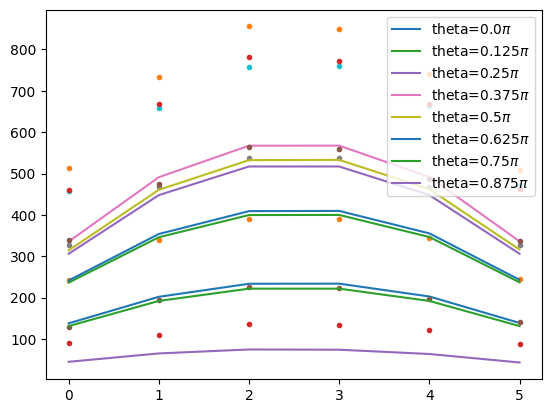

In [350]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner2_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner2_measured[t], '.')
plt.legend()

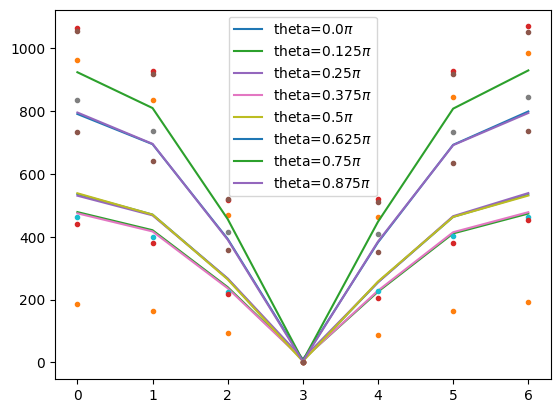

In [351]:
for t, theta in enumerate(thetas[:-1]):
    plt.plot(ner1_arr[t], label=r'theta={}$\pi$'.format(theta/np.pi))
    plt.plot(f_ner1_measured[t], '.')
plt.legend()

In [352]:
p_tensor = result.params.valuesdict()
_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas))
    fq2_arr   = np.zeros(len(thetas))
    ner1_arr  = np.zeros((len(thetas), 7))
    ner2_arr  = np.zeros((len(thetas), 6))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p_tensor, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p_tensor, **p)
        ner2_arr[t]  = ner2(theta, **p_tensor, **p)
    return np.hstack([
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
    ])

# scale_y ~ 270000 from NER1 outer transition (~1438 Hz measured)
# scale_z ~ 52000  from NER2 outer transition (~161  Hz measured)
# scale_x fixed at 0: both scale_x and scale_y drive NER1 ({Iy,Iz} vs {Ix,Iz})
#   and are poorly separated; leave scale_x free only if fit quality demands it
params = Parameters()
params.add('E_x', value=4,   min=-1e7, max=1e7)
params.add('E_y', value=-5,  min=-1e7, max=1e7)
params.add('E_z', value=10,   min=-1e7, max=1e7)
params.add('scale', value=1, min=0.00001, max=10)


result_full = minimize(residual_full, params, method='leastsq')
result_full


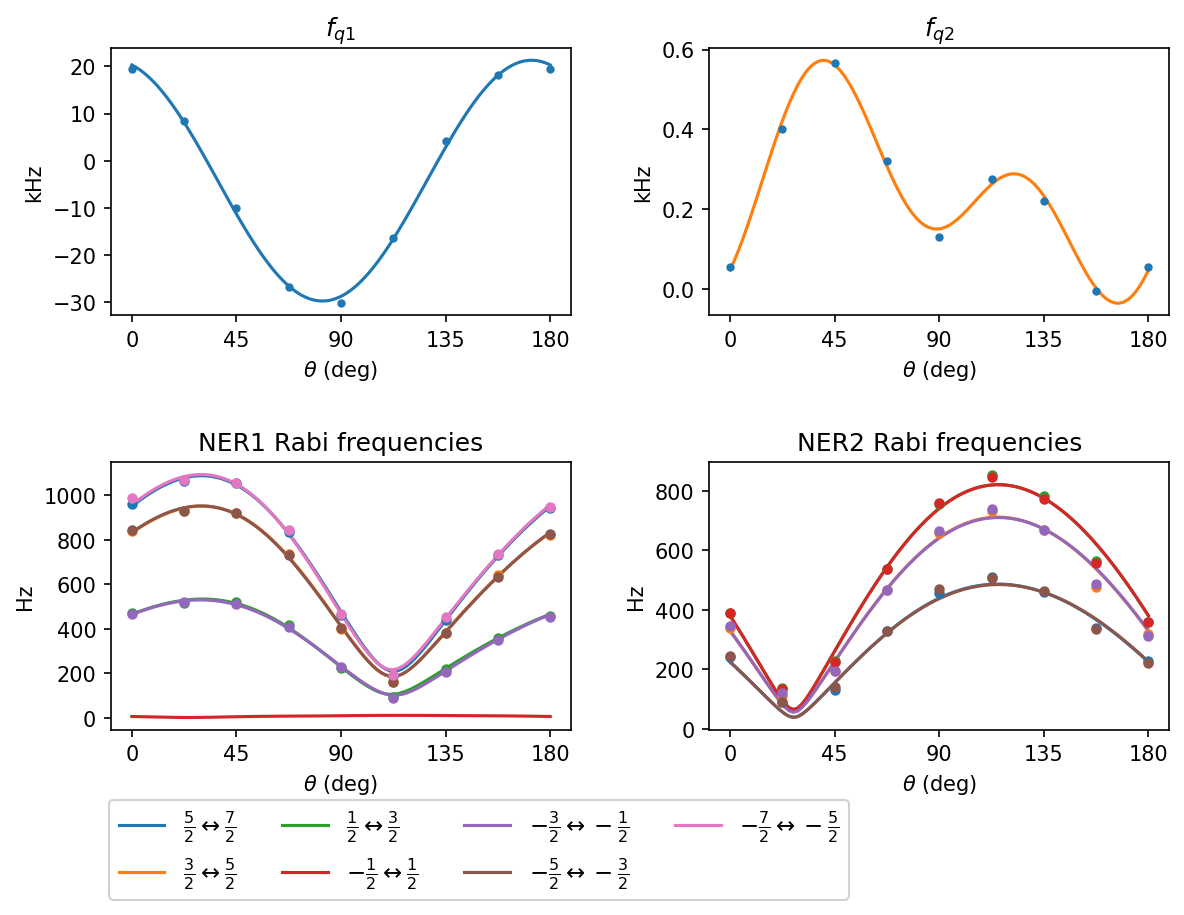

In [353]:

# Eigenstates in ascending energy order: ψ_0 = |m=+7/2⟩, ..., ψ_7 = |m=-7/2⟩
# NER1: H[i, i+1]  →  adjacent-m pairs
# NER2: H[i, i+2]  →  next-nearest-m pairs
_ner1_labels = [
    r'$\frac{5}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{3}{2}\leftrightarrow\frac{5}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{3}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{3}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{5}{2}$',
]
_ner2_labels = [
    r'$\frac{3}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{5}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{3}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{3}{2}$',
]

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_tensor, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_tensor, **p_full)
    ner2_fit[t]  = ner2(th, **p_tensor, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8,
                 color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=11, ncol=4, loc='upper center',
               bbox_to_anchor=(0.8, -0.22), framealpha=0.9)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
# axes[3].legend(fontsize=8, ncol=3, loc='upper center',
               # bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55, bottom=0.18)
plt.savefig(r'quadrupole_data.png', dpi=300)

## fit simultaneously

In [354]:
p_tensor = result.params.valuesdict()
_ner1_mask = f_ner1_measured != 0   # skip the symmetry-forbidden m=-1/2→+1/2 transition

def residual_full(params):
    p = params.valuesdict()
    fq1_arr   = np.zeros(len(thetas))
    fq2_arr   = np.zeros(len(thetas))
    ner1_arr  = np.zeros((len(thetas), 7))
    ner2_arr  = np.zeros((len(thetas), 6))
    lqse_arr = np.zeros(len(thetas))
    for t, theta in enumerate(thetas):
        evals = ionized_hamiltonian(theta, **p).eigenstates()[0]
        fq1_arr[t]   = np.mean(np.diff(np.diff(evals)))
        fq2_arr[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
        ner1_arr[t]  = ner1(theta, **p)
        ner2_arr[t]  = ner2(theta, **p)
        lqse_arr[t]  = lqse(theta, **p)
    return np.hstack([
        (fq1_arr - fq_1_measured) / np.max(fq_1_measured),
        (fq2_arr - fq_2_measured) / np.max(fq_2_measured),
        (ner1_arr - f_ner1_measured)[_ner1_mask]      / np.max(np.abs(f_ner1_measured[_ner1_mask])),
        (ner2_arr - f_ner2_measured).flatten()        / np.max(np.abs(f_ner2_measured)),
        (lqse_arr - lqse_measured)/ np.max(np.abs(lqse_measured)),
    ])

# scale_y ~ 270000 from NER1 outer transition (~1438 Hz measured)
# scale_z ~ 52000  from NER2 outer transition (~161  Hz measured)
# scale_x fixed at 0: both scale_x and scale_y drive NER1 ({Iy,Iz} vs {Ix,Iz})
#   and are poorly separated; leave scale_x free only if fit quality demands it
params = Parameters()
params.add('Vxx', value=5, min=-5,  max=5)
params.add('Vyy', value=3,  min=-5,  max=5)
params.add('Vzz', expr='- Vxx - Vyy')
params.add('Vxy', value=0,  min=-20, max=20)
params.add('Vyz', value=0,  min=-5,  max=20)
params.add('Vxz', value=0,  min=-5,  max=20)
params.add('E_x', value=-50266,   min=-1e7, max=1e7)
params.add('E_y', value=129098,  min=-1e7, max=1e7)
params.add('E_z', value=268649,   min=-1e7, max=1e7)
params.add('scale', value=1, min=0.00001, max=10)
params.add('scale_dc', value=-300000)


result_full = minimize(residual_full, params, method='leastsq')
result_full

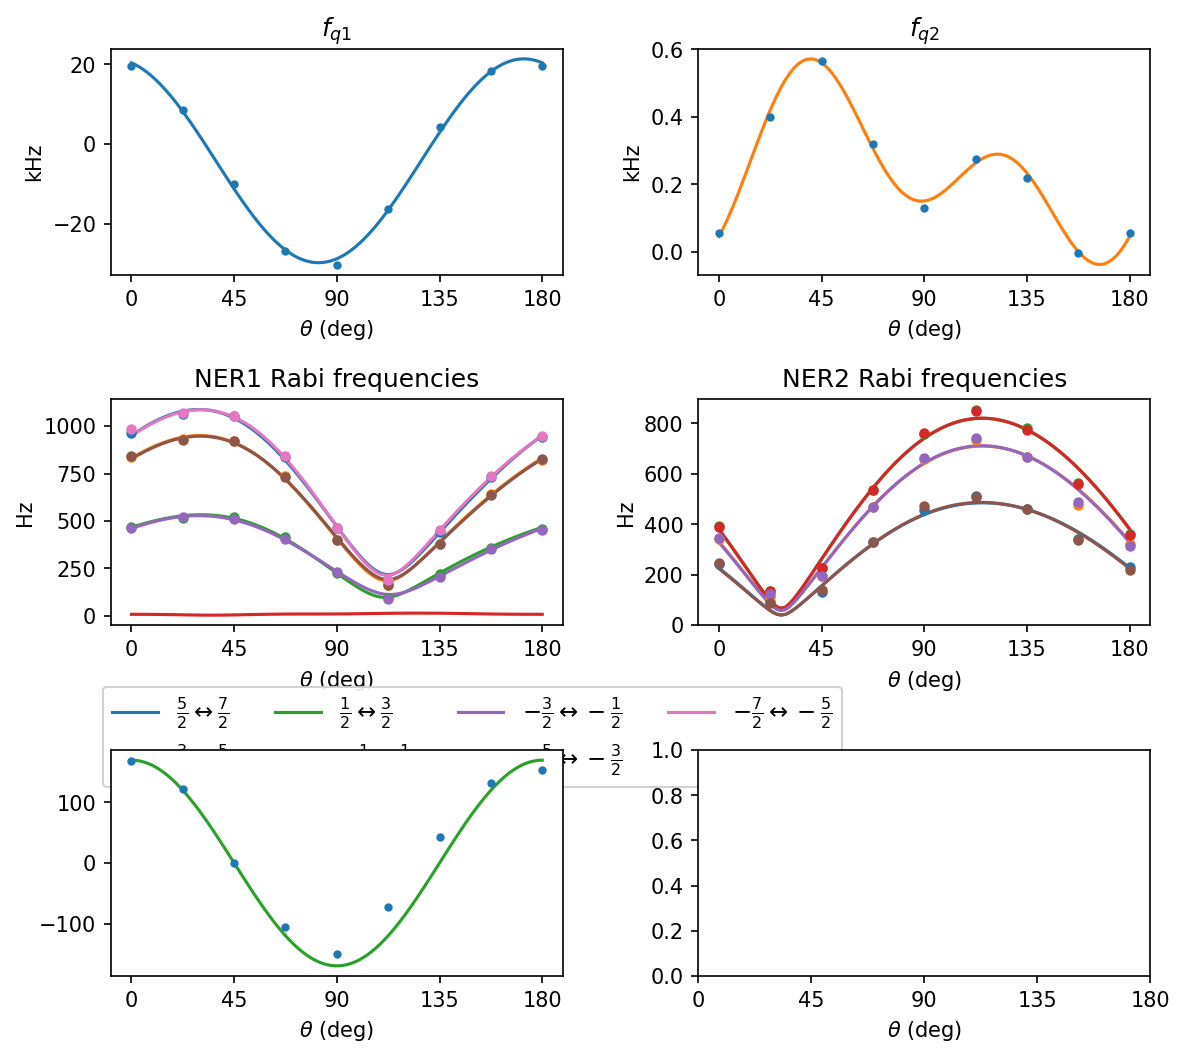

In [355]:

# Eigenstates in ascending energy order: ψ_0 = |m=+7/2⟩, ..., ψ_7 = |m=-7/2⟩
# NER1: H[i, i+1]  →  adjacent-m pairs
# NER2: H[i, i+2]  →  next-nearest-m pairs
_ner1_labels = [
    r'$\frac{5}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{3}{2}\leftrightarrow\frac{5}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{3}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{3}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{5}{2}$',
]
_ner2_labels = [
    r'$\frac{3}{2}\leftrightarrow\frac{7}{2}$',
    r'$\frac{1}{2}\leftrightarrow\frac{5}{2}$',
    r'$-\frac{1}{2}\leftrightarrow\frac{3}{2}$',
    r'$-\frac{3}{2}\leftrightarrow\frac{1}{2}$',
    r'$-\frac{5}{2}\leftrightarrow-\frac{1}{2}$',
    r'$-\frac{7}{2}\leftrightarrow-\frac{3}{2}$',
]

p_full = result_full.params.valuesdict()
thetas_fit = np.linspace(0, np.pi, 100)

fq1_fit  = np.zeros(len(thetas_fit))
fq2_fit  = np.zeros(len(thetas_fit))
ner1_fit = np.zeros((len(thetas_fit), 7))
ner2_fit = np.zeros((len(thetas_fit), 6))
lqse_fit = np.zeros(len(thetas_fit))
for t, th in enumerate(thetas_fit):
    evals = ionized_hamiltonian(th, **p_full).eigenstates()[0]
    fq1_fit[t]   = np.mean(np.diff(np.diff(evals)))
    fq2_fit[t]   = np.mean(np.diff(np.diff(np.diff(evals))))
    ner1_fit[t]  = ner1(th, **p_full)
    ner2_fit[t]  = ner2(th, **p_full)
    lqse_fit[t]  = lqse(th, **p_full)

theta_deg     = thetas / np.pi * 180
theta_fit_deg = thetas_fit / np.pi * 180
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(3, 2, figsize=(8, 8), dpi=150)
axes = ax.flatten()

axes[0].plot(theta_deg, fq_1_measured * 1e-3, '.', zorder=5)
axes[0].plot(theta_fit_deg, fq1_fit * 1e-3, color='C0')
axes[0].set_title('$f_{q1}$')
axes[0].set_ylabel('kHz')

axes[1].plot(theta_deg, fq_2_measured * 1e-3, '.', zorder=5)
axes[1].plot(theta_fit_deg, fq2_fit * 1e-3, color='C1')
axes[1].set_title('$f_{q2}$')
axes[1].set_ylabel('kHz')

for i in range(7):
    mask_i = _ner1_mask[:, i]
    c = colors[i % len(colors)]
    axes[2].plot(theta_deg[mask_i], f_ner1_measured[mask_i, i], '.', markersize=8,
                 color=c, zorder=5)
    axes[2].plot(theta_fit_deg, ner1_fit[:, i], color=c, label=_ner1_labels[i])
axes[2].set_title('NER1 Rabi frequencies')
axes[2].set_ylabel('Hz')
axes[2].legend(fontsize=11, ncol=4, loc='upper center',
               bbox_to_anchor=(0.8, -0.22), framealpha=0.9)

for i in range(6):
    c = colors[i % len(colors)]
    axes[3].plot(theta_deg, f_ner2_measured[:, i], '.', markersize=8, color=c, zorder=5)
    axes[3].plot(theta_fit_deg, ner2_fit[:, i], color=c, label=_ner2_labels[i])
axes[3].set_title('NER2 Rabi frequencies')
axes[3].set_ylabel('Hz')
# axes[3].legend(fontsize=8, ncol=3, loc='upper center',
               # bbox_to_anchor=(0.5, -0.22), framealpha=0.9)

axes[4].plot(theta_deg, lqse_measured, '.', zorder=5)
axes[4].plot(theta_fit_deg, 1.1*lqse_fit, color='C2')

for a in axes:
    a.set_xlabel(r'$\theta$ (deg)')
    a.set_xticks([0, 45, 90, 135, 180])

fig.tight_layout()
fig.subplots_adjust(wspace=0.3, hspace=0.55, bottom=0.18)
plt.savefig(r'quadrupole_data.png', dpi=300)

# visualize the tensor

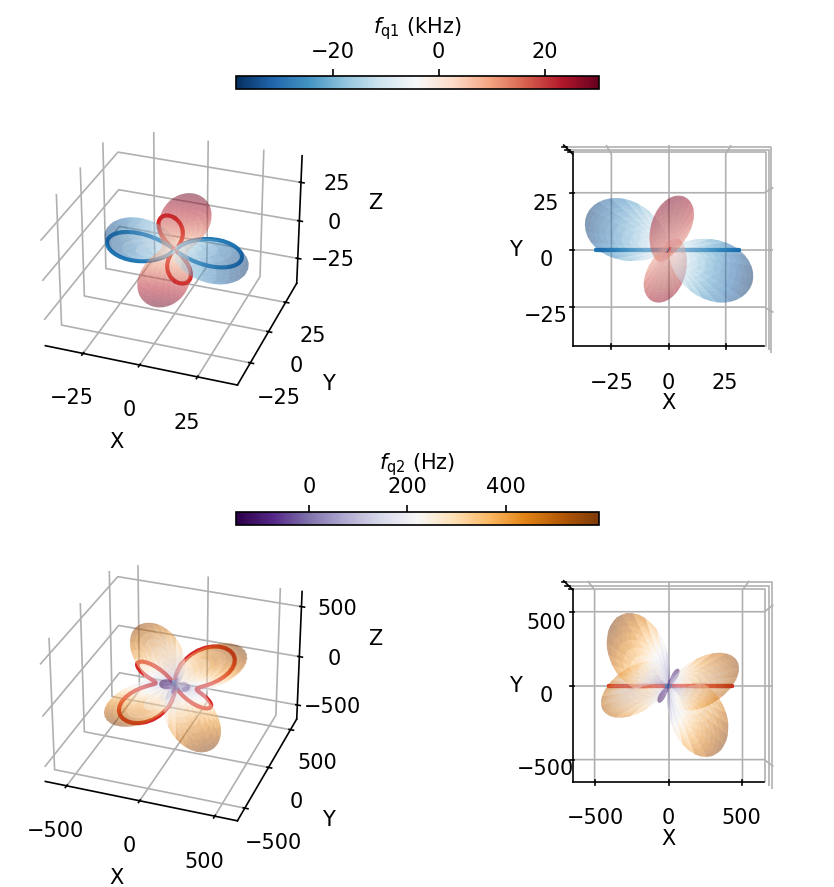

In [356]:
Vxx = p_tensor['Vxx']
Vyy = p_tensor['Vyy']
Vzz = p_tensor['Vzz']
Vxy = p_tensor['Vxy']
Vyz = p_tensor['Vyz']
Vxz = p_tensor['Vxz']
V_ab = np.array([[Vxx, Vxy, Vxz], [Vxy, Vyy, Vyz], [Vxz, Vyz, Vzz]]) * 1e19

plot_quadrupole_tensor(V_ab, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, peanut_offset=0)
plt.savefig(r'quad_tensor.png', dpi=300)

In [366]:
theta_grid = np.linspace(0, np.pi, 100)
phi_grid = np.linspace(0, 2*np.pi, 100)
fq1_grid = get_fq1(V_ab, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, theta_grid, phi_grid)
fq2_grid = get_fq2(V_ab, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, theta_grid, phi_grid)

In [367]:
idx_max

(array([20]), array([45]))

30160.234065764893
143.63636363636365 261.8181818181818


Text(0, 0.5, 'theta')

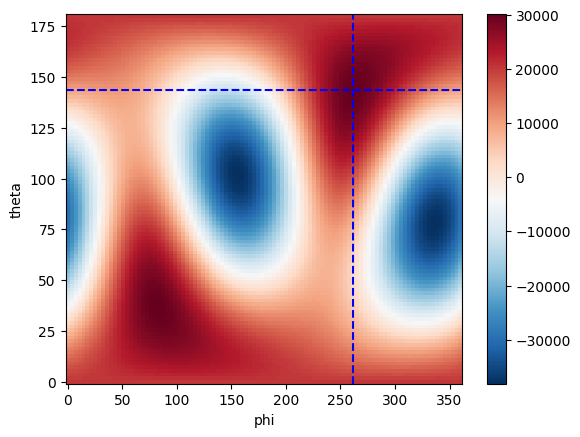

In [368]:
plt.pcolormesh(phi_grid/np.pi*180, theta_grid/np.pi*180, fq1_grid, cmap='RdBu_r')
plt.colorbar()

idx_max = np.where(fq1_grid == fq1_grid.max())
phi_max = phi_grid[idx_max[1][0]]/np.pi*180
theta_max = theta_grid[idx_max[0][0]]/np.pi*180
plt.axhline(theta_max, color='b', linestyle='--')
plt.axvline(phi_max, color='b', linestyle='--')

print(fq1_grid.max())

print(theta_max, phi_max)

plt.xlabel('phi')
plt.ylabel('theta')

In [369]:
print("Prediction:")
print(fq1_grid[idx_max][0])
print(fq2_grid[idx_max][0])

f_nmr = [5077256, 5107878, 5138477, 5168952, 5199363, 5229722, 5260114]
print("Measured:")
print(np.mean(np.diff(f_nmr)))
print(np.mean(np.diff(np.diff(f_nmr))))

Prediction:
30160.234065764893
-67.59728087820113
Measured:
30476.333333333332
-46.0


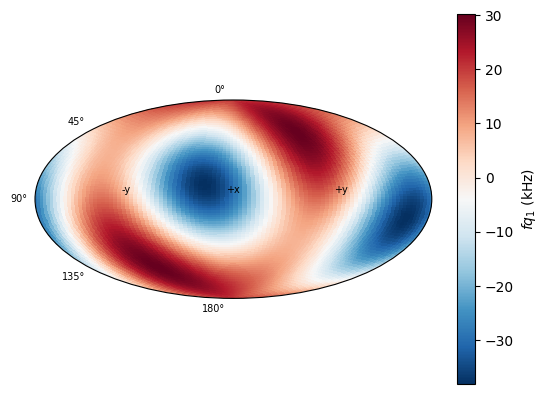

In [370]:
fig, ax, pcm = spherical_plot_hammer(fq1_grid*1e-3, cmap='RdBu_r')
plt.colorbar(pcm, label=r'$fq_1$ (kHz)')

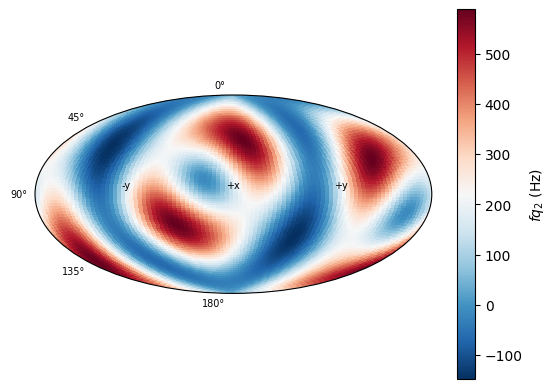

In [371]:
fig, ax, pcm = spherical_plot_hammer(fq2_grid, cmap='RdBu_r')
plt.colorbar(pcm, label=r'$fq_2$ (Hz)')

aa# Play around with visualization

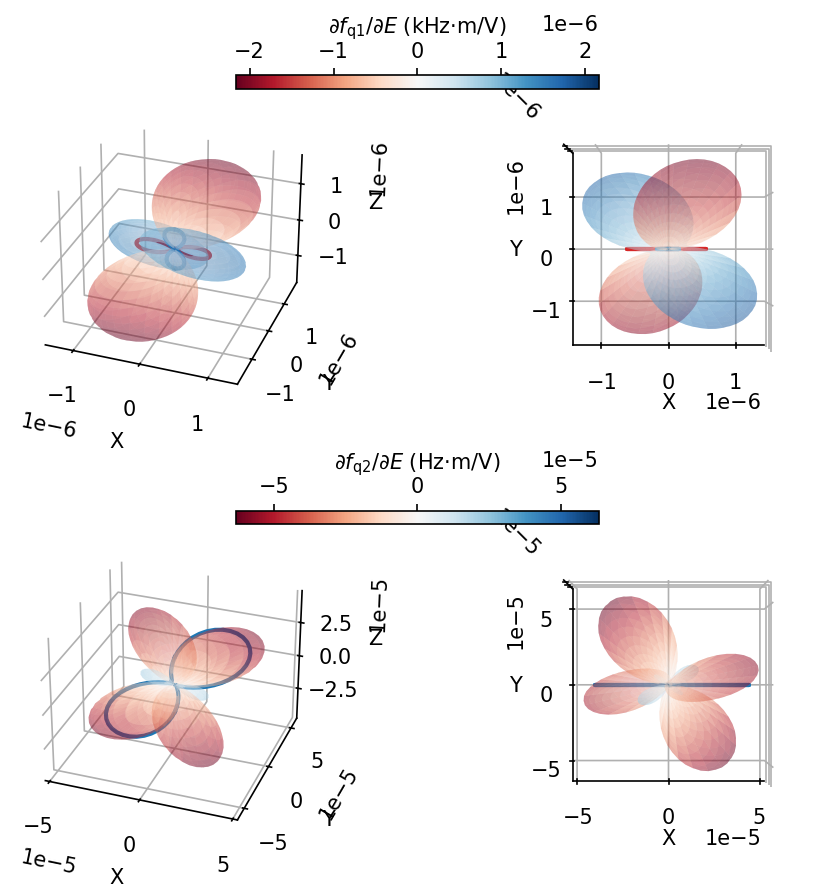

In [372]:
from psyduck.hamiltonians import get_quadrupole_stark_shift
from psyduck.plotting import plot_quadrupole_stark_shift

E_vec = np.array([p_full['E_x'], p_full['E_y'], p_full['E_z']])
thetas_ss = np.linspace(0, np.pi, 50)
phis_ss = np.linspace(0, 2 * np.pi, 100)

dfq1_stark, dfq2_stark = get_quadrupole_stark_shift(
    V_ab, E_vec, I_SPIN, B0, GAMMA_NUCLEAR, Q_N, thetas_ss, phis_ss
)

plot_quadrupole_stark_shift(dfq1_stark, dfq2_stark, thetas_ss, phis_ss)

In [373]:
q_stark_shift_measured = np.array([100/0.75, 88.529, -5.351, -102.260, -135.221, -72.705, 43.519])

ValueError: x and y must have same first dimension, but have shapes (9,) and (7,)

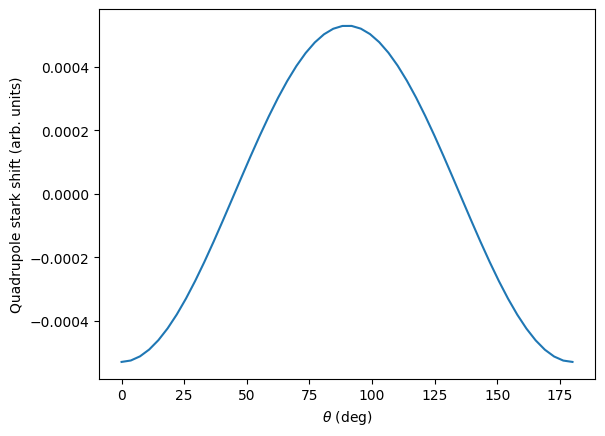

In [365]:
fig, ax = plt.subplots(1,1)
ax.plot(thetas_ss/np.pi*180, dfq1_stark[:, 0])
ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel(r'Quadrupole stark shift (arb. units)')
scale_dc_gate = 4.7e-6

ax.plot(thetas/np.pi*180, q_stark_shift_measured*-scale_dc_gate, '.', markersize=10)
plt.axhline(0)
plt.savefig(r'lqse.png', dpi=300)

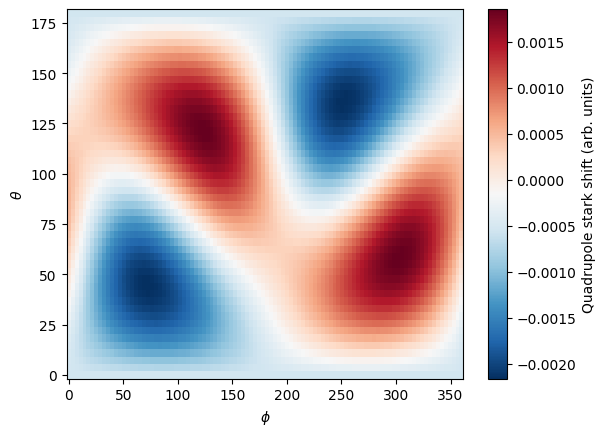

In [374]:
plt.pcolormesh(phis_ss/np.pi*180, thetas_ss/np.pi*180, dfq1_stark, cmap='RdBu_r')
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\theta$')
plt.colorbar(label=r'Quadrupole stark shift (arb. units)')

In [375]:
dfq1_stark.shape

(50, 100)

Text(0.5, 0, 'Z')

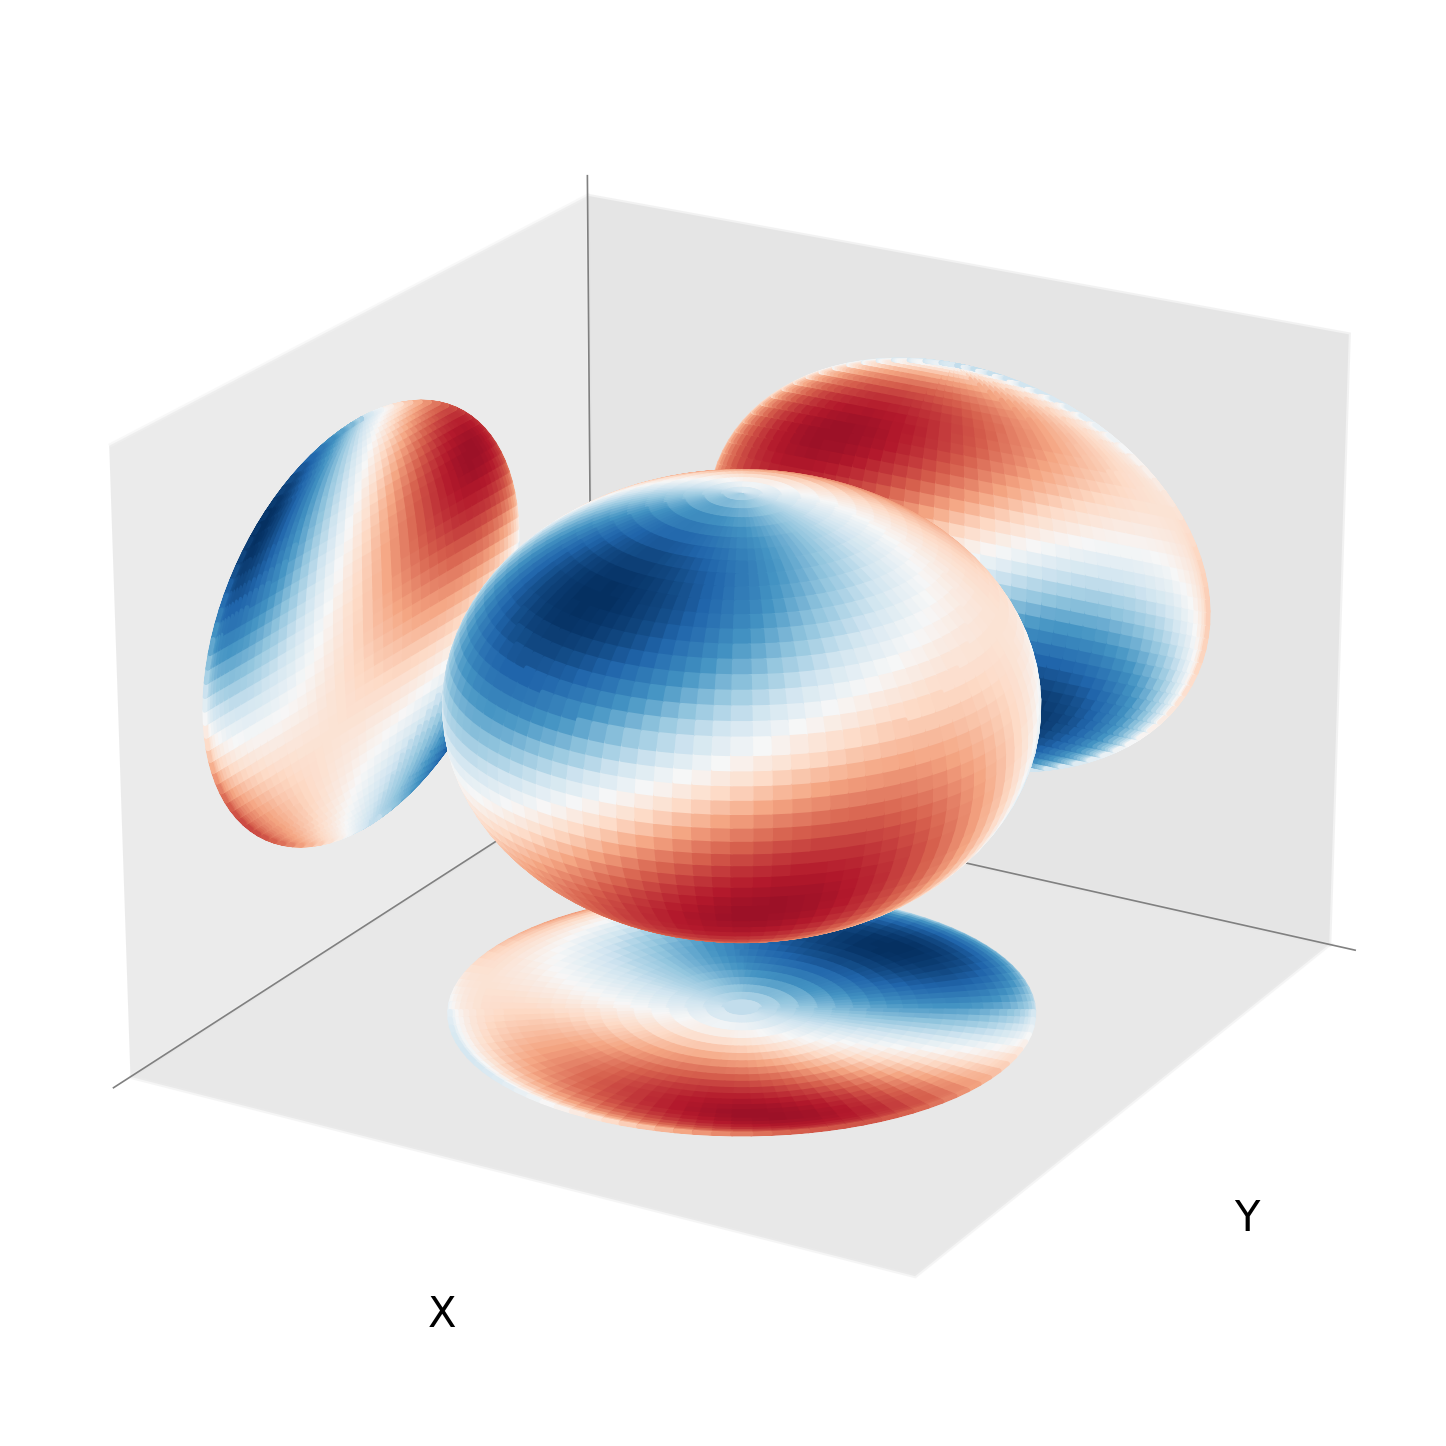

In [376]:
fig, ax, pcm = spherical_plot_3d_with_projections(dfq1_stark, vmin=-np.abs(dfq1_stark).max(),
                                                  vmax=np.abs(dfq1_stark).max(), cmap='RdBu_r')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# predict next nmr frequencies

In [ ]:
theta_next = 157.5 / 180 * np.pi

# Model curve over all angles (quadrupole tensor only, fixed B0)
thetas_model = np.linspace(0, np.pi, 200)
nmr_model = np.array([nmr_frequencies(th, **p_tensor) for th in thetas_model])
nmr_pred = nmr_frequencies(theta_next, **p_tensor)

# Sinusoidal fit to center frequency (nmr[:, 3]) to capture B0 variation
# Exclude first two angles (different B0)
valid = slice(2, None)
A = np.column_stack([np.ones_like(thetas[valid]),
                     np.cos(2 * thetas[valid]),
                     np.sin(2 * thetas[valid])])
coeffs, _, _, _ = np.linalg.lstsq(A, nmr[valid, 3], rcond=None)

def center_sinusoid(theta):
    return coeffs[0] + coeffs[1] * np.cos(2 * theta) + coeffs[2] * np.sin(2 * theta)

center_pred_extrapolated = center_sinusoid(theta_next)

# Shift model curve and predicted point by the B0 correction at each angle
b0_correction_model = center_sinusoid(thetas_model) - nmr_model[:, 3]
nmr_model_b0 = nmr_model + b0_correction_model[:, np.newaxis]

offsets_pred = nmr_pred - nmr_pred[3]
nmr_adjusted = center_pred_extrapolated + offsets_pred

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thetas / np.pi * 180, nmr, '.', markersize=7)

ax.plot(thetas[0:2] / np.pi * 180, nmr[0:2] * 0.999 / 0.974, '.', markersize=7, color='grey')

ax.plot(thetas_model / np.pi * 180, nmr_model_b0, 'k-', alpha=0.3, linewidth=1)
ax.plot([157.5] * 7, nmr_adjusted, 'r*', markersize=10, label='predicted 157.5°')
ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel('Frequency (Hz)')
ax.set_xticks([0, 45, 90, 135, 157.5, 180])
ax.legend()
plt.tight_layout()

In [ ]:
fq1_pred = np.mean(np.diff(nmr_pred))
fq2_pred = np.mean(np.diff(np.diff(nmr_pred)))

print(f"Predicted at θ = 157.5°")
print(f"  Center (sinusoidal B0 trend): {center_pred_extrapolated:.0f} Hz  =  {center_pred_extrapolated/1e6:.6f} MHz")
print(f"  fq1:  {fq1_pred/1e3:+.3f} kHz")
print(f"  fq2:  {fq2_pred:.1f} Hz")
print()
print("Transition frequencies:", np.round(nmr_adjusted*0.974).astype(int).tolist())

# Diagnostic: center frequency vs angle with sinusoidal fit
theta_curve = np.linspace(0, np.pi, 200)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(thetas[2:-2] / np.pi * 180, nmr[2:-2, 3], 'x', color='gray', label='excluded (diff. B0)')
ax.plot(thetas[2:-2] / np.pi * 180, nmr[2:-2, 3], '.', markersize=8, label='measured')
ax.plot(theta_curve / np.pi * 180, center_sinusoid(theta_curve), 'k--', label='sinusoidal fit')
ax.plot(157.5, center_pred_extrapolated, 'r*', markersize=10, label=f'{center_pred_extrapolated:.0f} Hz')
ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel('Center frequency (Hz)')
ax.set_xticks([0, 45, 90, 135, 157.5, 180])
ax.legend()
plt.tight_layout()

In [ ]:
26178250000/5200

In [ ]:
plt.plot(esr/nmr[3])

In [160]:
f_ESR = 27184250000.0
esr = np.array([int(f_ESR - 691.85e6 + 26.5e6), int(f_ESR - 916.76e6), int(f_ESR - 1042.12e6), int(f_ESR - 1972.36e6),
                int(f_ESR - 2424.72e6), int(f_ESR - 2116.78e6 + 4.6e6), int(f_ESR - 1272.44e6)])

# Sinusoidal fit to ESR frequencies (same form as NMR center: a + b·cos(2θ) + c·sin(2θ))
A_esr = np.column_stack([np.ones_like(thetas[valid]),
                         np.cos(2 * thetas[valid]),
                         np.sin(2 * thetas[valid])])
coeffs_esr, _, _, _ = np.linalg.lstsq(A_esr, esr[valid], rcond=None)

def esr_sinusoid(theta):
    return coeffs_esr[0] + coeffs_esr[1] * np.cos(2 * theta) + coeffs_esr[2] * np.sin(2 * theta)

esr_pred = esr_sinusoid(theta_next)

print(f"Predicted ESR frequency at θ = 157.5°:  {esr_pred:.0f} Hz  =  {esr_pred/1e9:.6f} GHz")

# Diagnostic plot
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(thetas[:2] / np.pi * 180, esr[:2], 'x', color='gray', label='excluded (diff. B0)')
ax.plot(thetas[:2] / np.pi * 180, esr[:2]*0.999/0.974, 'x', color='red', label='corrected (diff. B0)')
ax.plot(thetas[2:] / np.pi * 180, esr[2:], '.', markersize=8, label='measured')
ax.plot(theta_curve / np.pi * 180, esr_sinusoid(theta_curve), 'k--', label='sinusoidal fit')
ax.plot(157.5, esr_pred, 'r*', markersize=10, label=f'{esr_pred:.0f} Hz')
ax.plot(157.5, esr_pred*0.974/0.999, '*', markersize=10, color='grey', label=f'{esr_pred*0.974/0.999:.0f} Hz')

ax.set_xlabel(r'$\theta$ (deg)')
ax.set_ylabel('ESR frequency (Hz)')
ax.set_xticks([0, 45, 90, 135, 157.5, 180])
ax.legend()
plt.tight_layout()

LinAlgError: Incompatible dimensions

In [ ]:
f_ESR = 27184250000.0
esr = np.array([int(f_ESR - 691.85e6 + 26.5e6), int(f_ESR - 916.76e6), int(f_ESR - 1042.12e6), int(f_ESR - 1972.36e6 ),  int(f_ESR - 2424.72e6), int(f_ESR - 2116.78e6 + 4.6e6), int(f_ESR - 1272.44e6) ])

In [ ]:
(esr_pred*0.974/0.999 - f_ESR)/1e6

In [ ]:
plt.plot(esr/nmr[3])

# 2D prediction maps for NER1 and NER2 Rabi frequencies

In [237]:
_n_theta = 100
_n_phi   = 100
_thetas_2d = np.linspace(0, np.pi, _n_theta)
_phis_2d   = np.linspace(0, 2 * np.pi, _n_phi)

_ner1_grid = np.zeros((_n_theta, _n_phi, 7))
_ner2_grid = np.zeros((_n_theta, _n_phi, 6))

for _i, _th in enumerate(_thetas_2d):
    for _j, _ph in enumerate(_phis_2d):
        _ner1_grid[_i, _j] = ner1(_th, phi=_ph, **p_full)
        _ner2_grid[_i, _j] = ner2(_th, phi=_ph, **p_full)

In [238]:
_ner1_grid[56, 43, :]

array([424.80801386, 370.15942814, 206.21546632,   1.20016263,
       207.91839708, 370.64919255, 423.86612391])

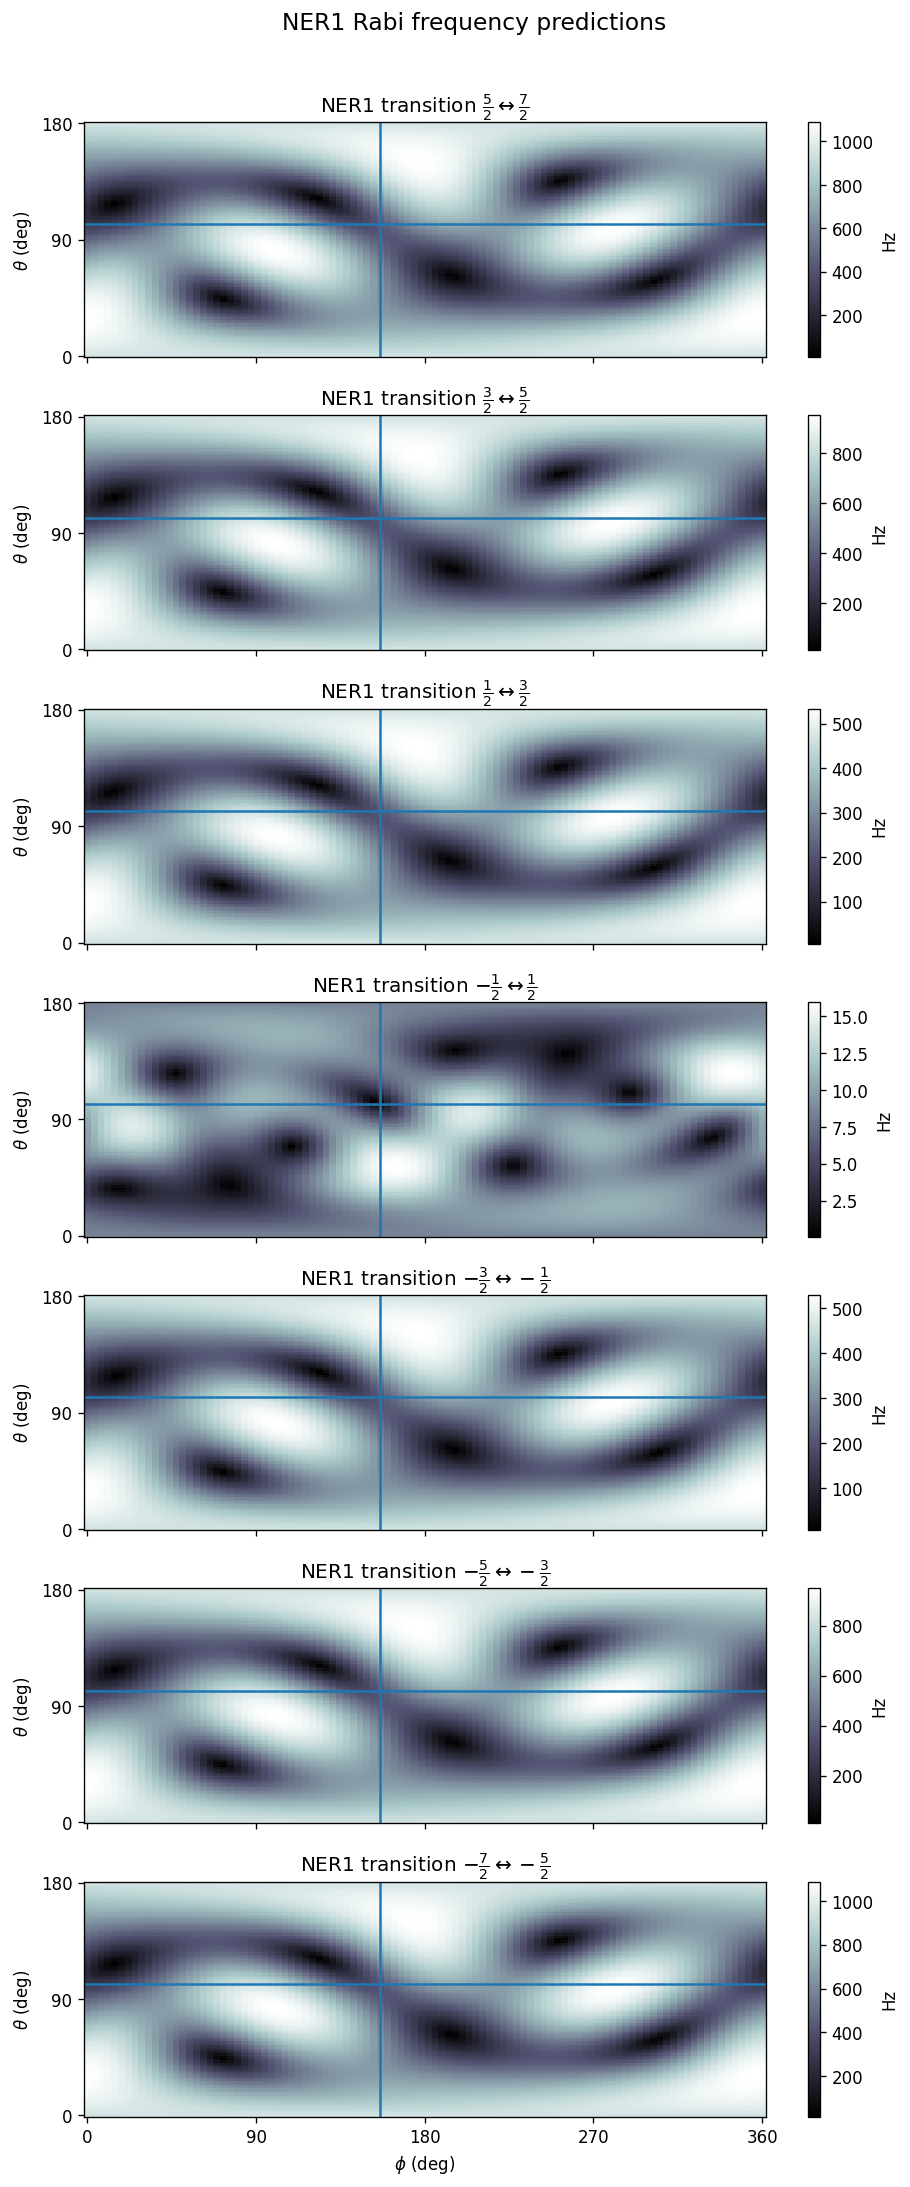

In [239]:
_phi_deg   = _phis_2d / np.pi * 180
_theta_deg = _thetas_2d / np.pi * 180

fig, axes = plt.subplots(7, 1, figsize=(8, 18), dpi=120, sharex=True)
for i, (ax, label) in enumerate(zip(axes, _ner1_labels)):
    pcm = ax.pcolormesh(_phi_deg, _theta_deg, _ner1_grid[:, :, i], shading='auto', cmap='bone')
    fig.colorbar(pcm, ax=ax, label='Hz')
    ax.set_ylabel(r'$\theta$ (deg)')
    ax.set_title(f'NER1 transition {label}')
    ax.set_yticks([0, 90, 180])
    ax.axhline(_theta_deg[56])
    ax.axvline(_phi_deg[43])

axes[-1].set_xlabel(r'$\phi$ (deg)')
axes[-1].set_xticks([0, 90, 180, 270, 360])
fig.suptitle('NER1 Rabi frequency predictions', fontsize=14, y=1.01)
fig.tight_layout()
plt.savefig('ner1_2d_map.png', dpi=150, bbox_inches='tight')

In [246]:
0.5/_ner1_grid[56, 43, :]*1000

array([  1.17700228,   1.35076932,   2.4246484 , 416.61020434,
         2.40478961,   1.34898446,   1.17961774])

In [241]:
0.5/_ner2_grid[56, 43, :]*1000

array([1.35862114, 0.92653705, 0.80102095, 0.79961974, 0.92168269,
       1.34677571])

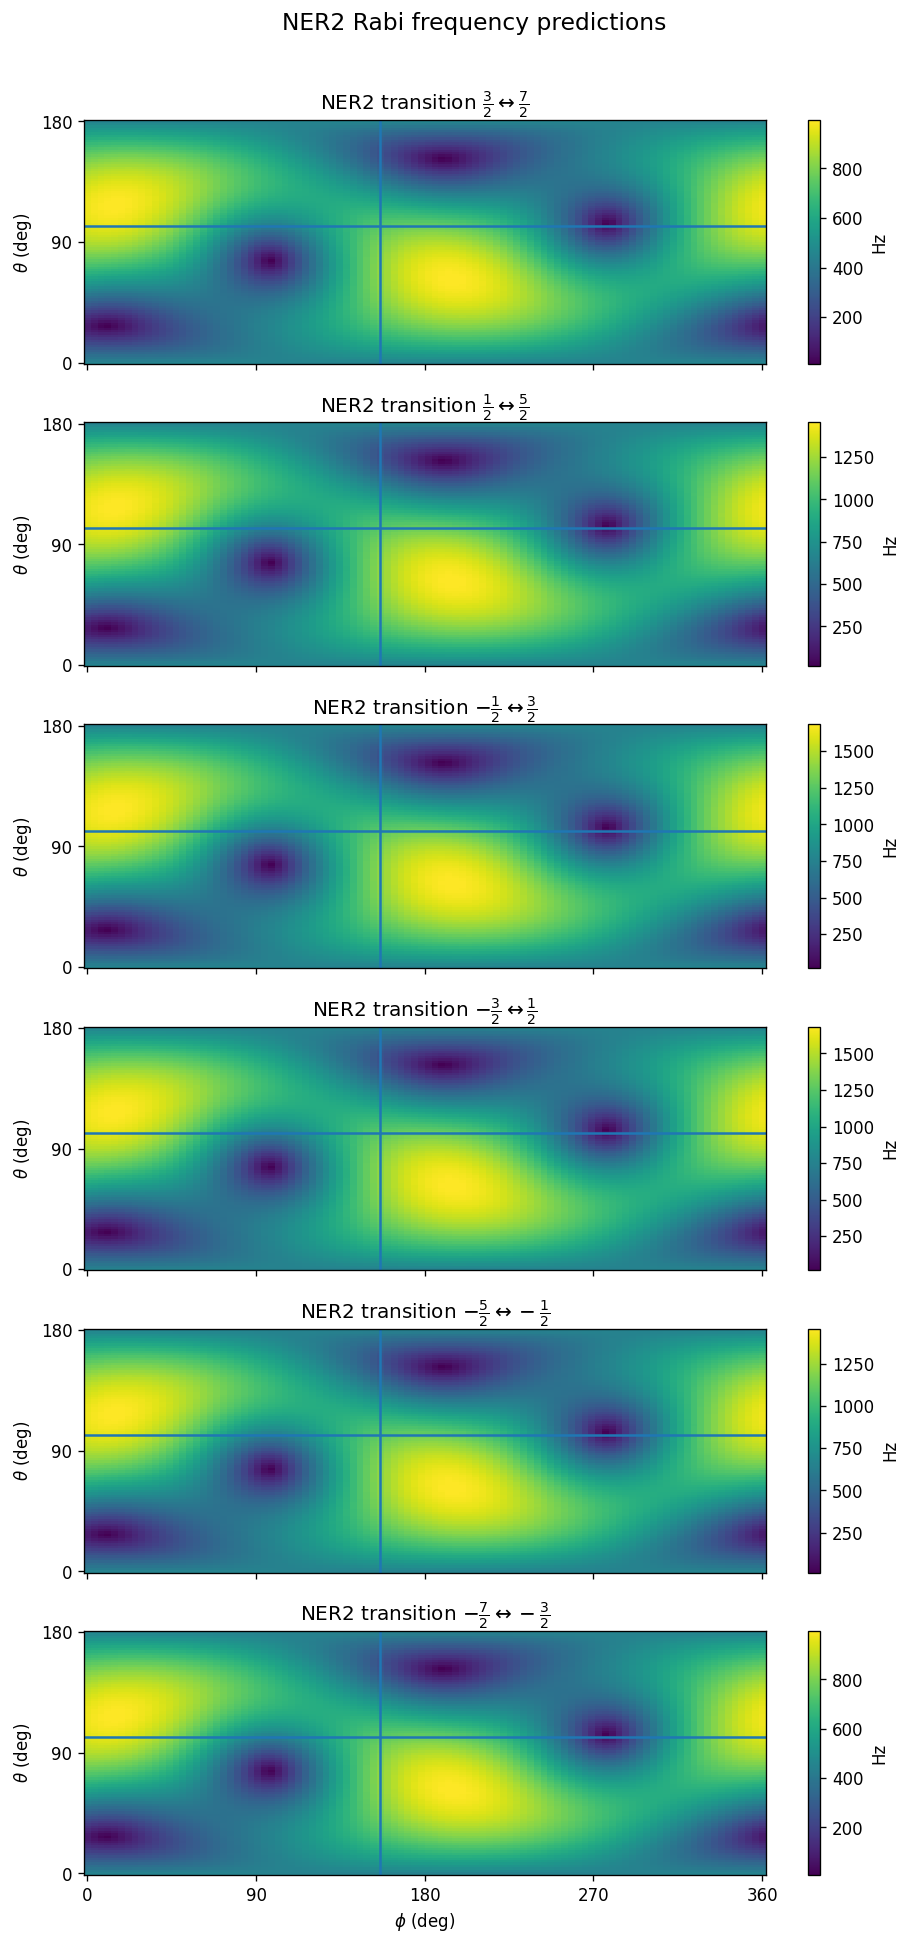

In [157]:
fig, axes = plt.subplots(6, 1, figsize=(8, 16), dpi=120, sharex=True)
for i, (ax, label) in enumerate(zip(axes, _ner2_labels)):
    pcm = ax.pcolormesh(_phi_deg, _theta_deg, _ner2_grid[:, :, i], shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Hz')
    ax.set_ylabel(r'$\theta$ (deg)')
    ax.set_title(f'NER2 transition {label}')
    ax.set_yticks([0, 90, 180])
    ax.axhline(_theta_deg[56])
    ax.axvline(_phi_deg[43])

axes[-1].set_xlabel(r'$\phi$ (deg)')
axes[-1].set_xticks([0, 90, 180, 270, 360])
fig.suptitle('NER2 Rabi frequency predictions', fontsize=14, y=1.01)
fig.tight_layout()
plt.savefig('ner2_2d_map.png', dpi=150, bbox_inches='tight')

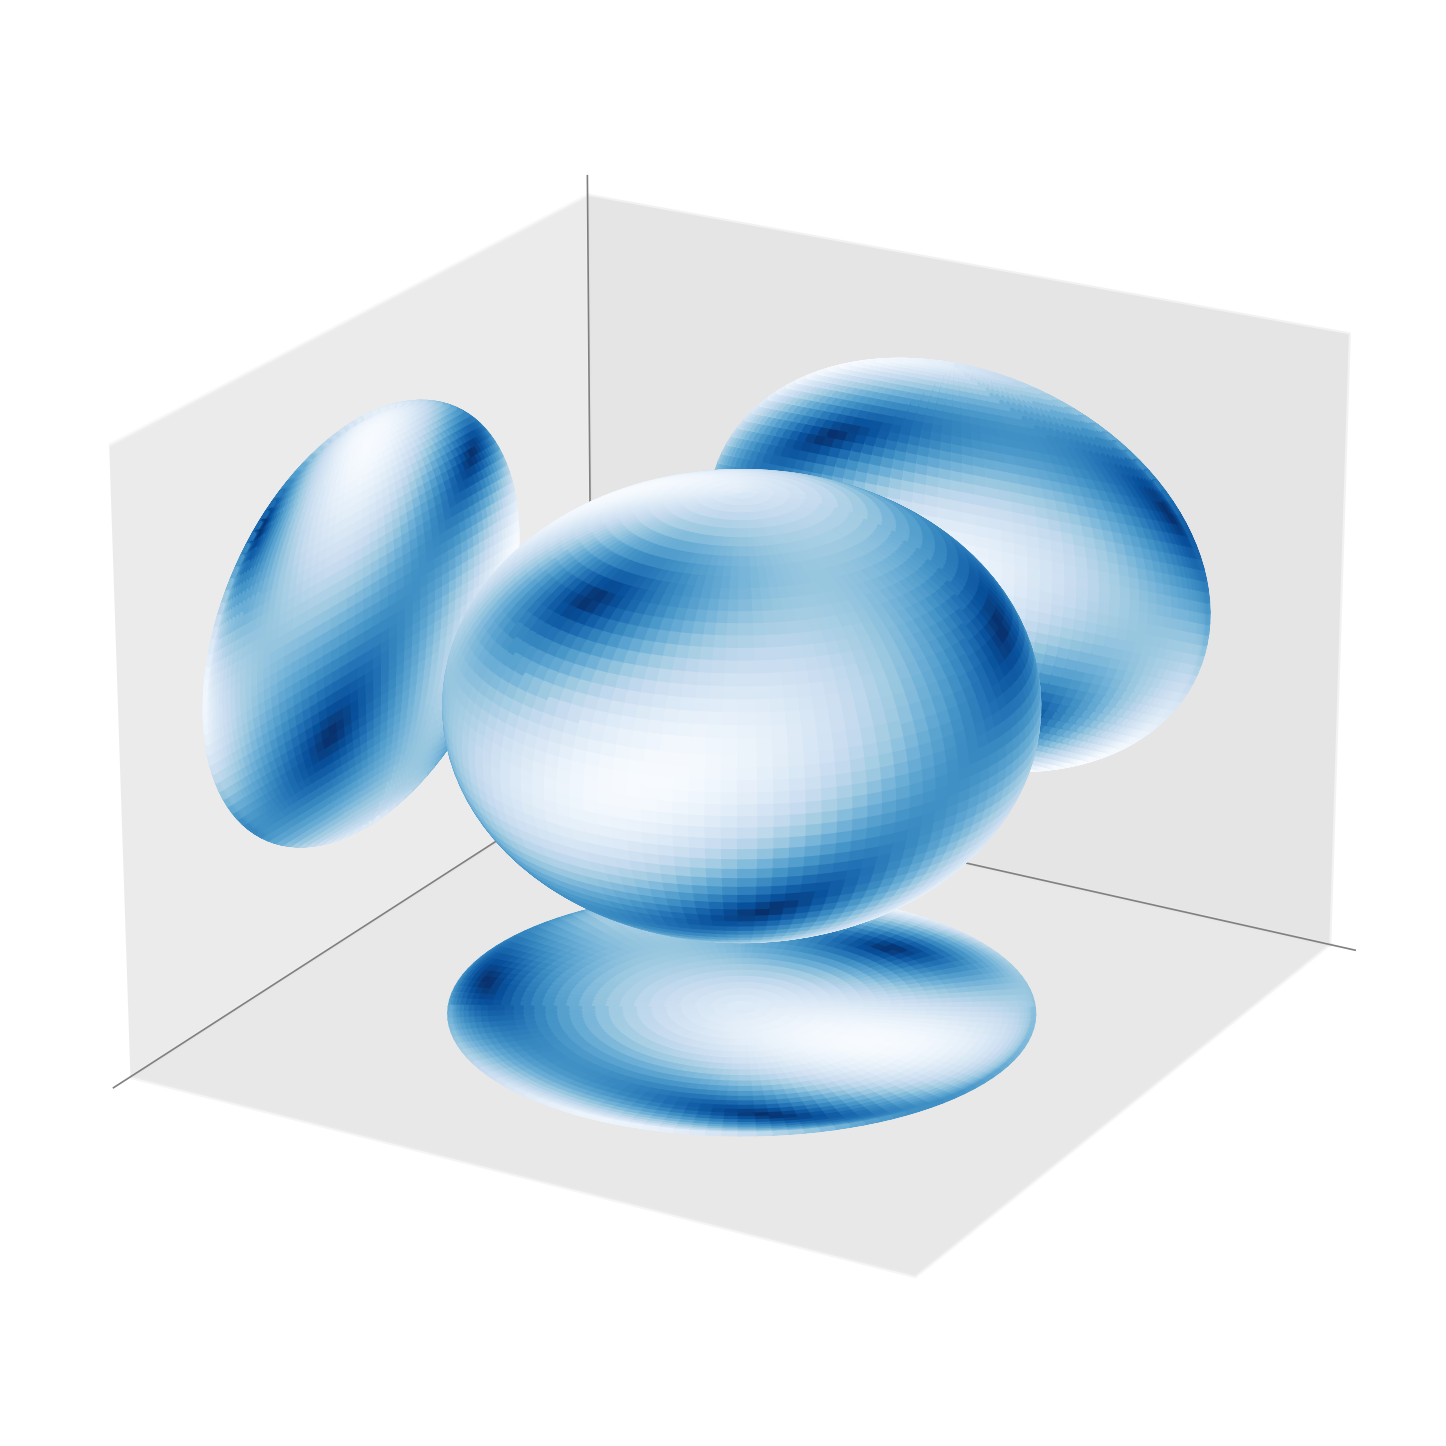

In [138]:
fig, ax, pcm = spherical_plot_3d_with_projections(_ner1_grid[:, :, -1], cmap='Blues_r')

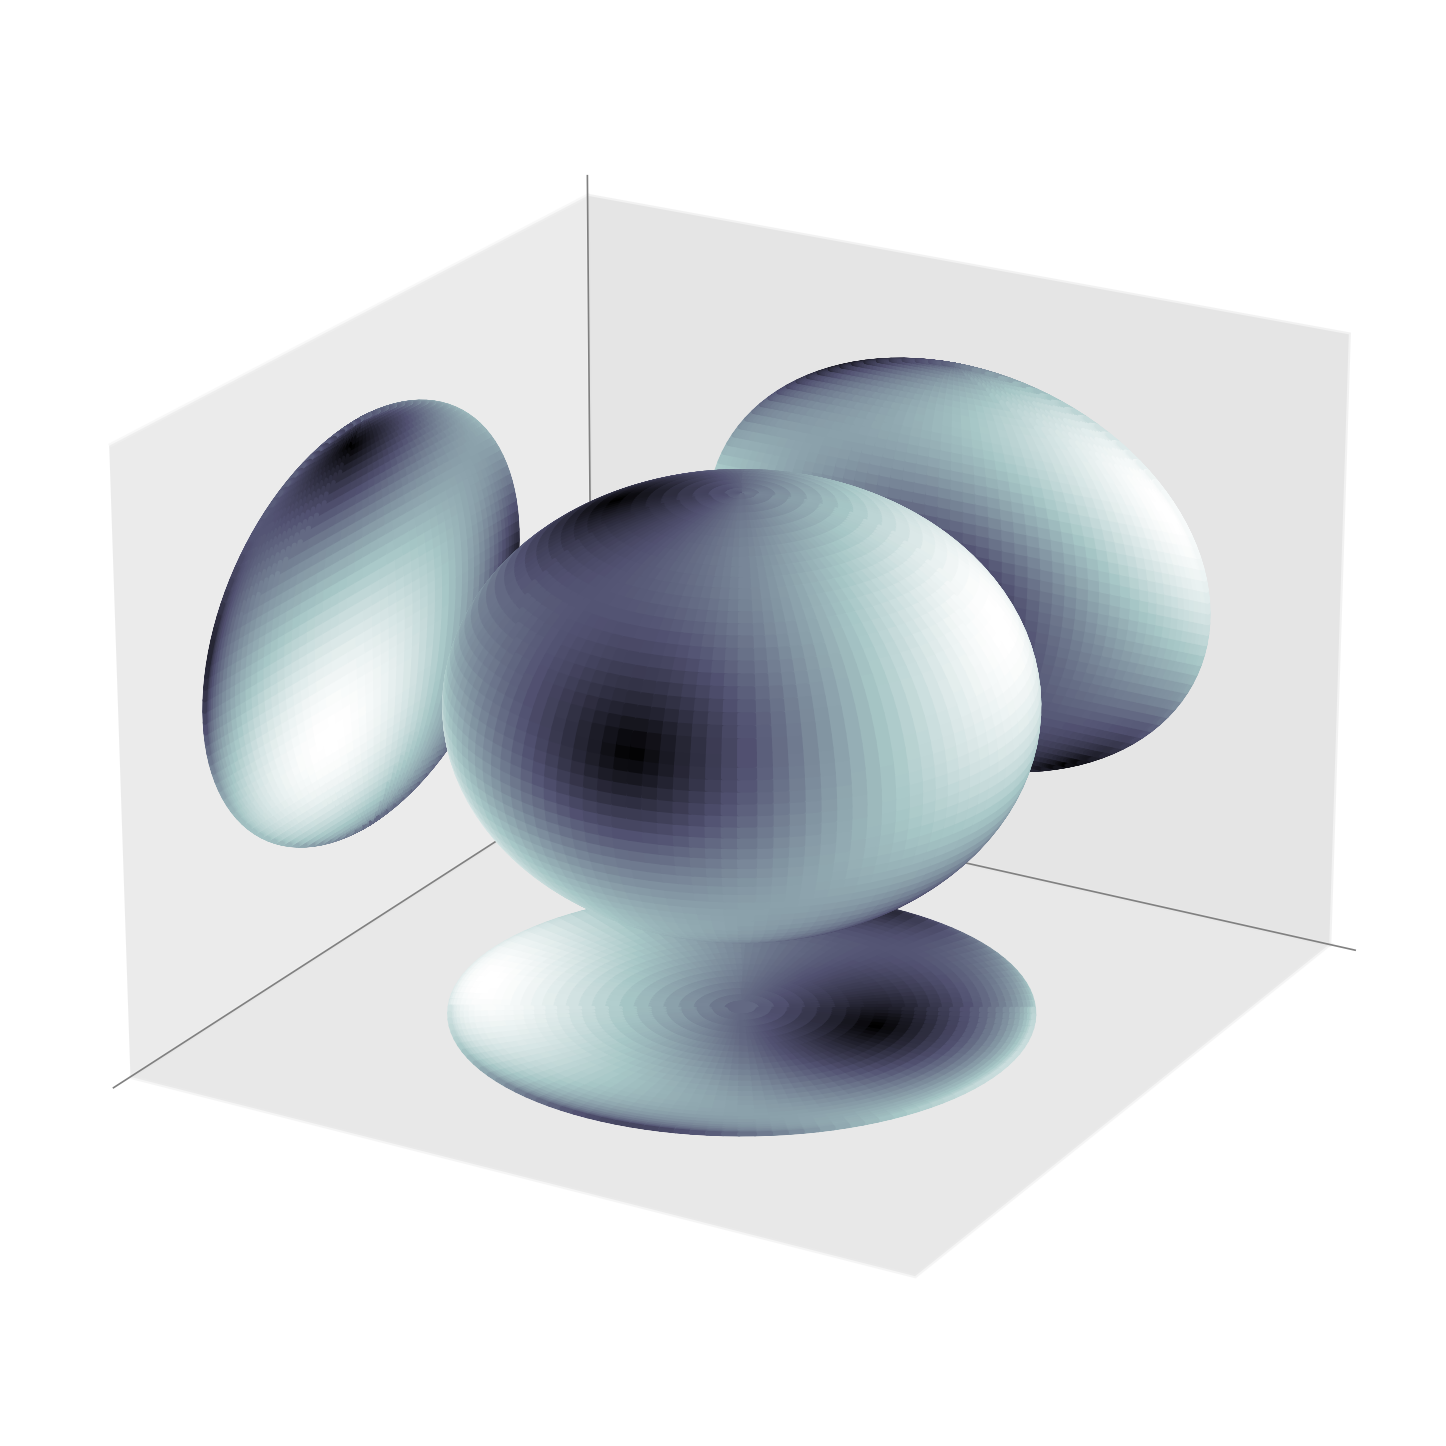

In [139]:
fig, ax, pcm = spherical_plot_3d_with_projections(_ner2_grid[:, :, -1], cmap='bone')

In [262]:
f_q = 30160.234065773897
f_c = 5034278
f_nmr = np.zeros(7)
for i in range(7):
    f_nmr[i] = int(f_c + (i-3)*f_q)

In [263]:
f_nmr

array([4943797., 4973957., 5004117., 5034278., 5064438., 5094598.,
       5124758.])

In [264]:
np.diff(f_nmr)

array([30160., 30160., 30161., 30160., 30160., 30160.])

In [276]:
np.mean(np.diff([5077256, 5107878, 5138477, 5168952, 5199363, 5229722, 5260114]))

np.float64(30476.333333333332)

In [277]:
np.mean(np.diff(np.diff([5077256, 5107878, 5138477, 5168952, 5199363, 5229722, 5260114])))

np.float64(-46.0)